In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [39]:
!pip install -q scikit-image   # for CLAHE

import os, random, math, gc, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from skimage import exposure             # CLAHE

from   albumentations import (
        HorizontalFlip, VerticalFlip, Rotate, ShiftScaleRotate,
        RandomCrop, RandomBrightnessContrast, Compose, OneOf
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from tensorflow.keras.metrics import AUC
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, Dense, GlobalAveragePooling2D,
                                     Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (ModelCheckpoint, ReduceLROnPlateau,
                                        EarlyStopping)

In [21]:
SEED        = 42
IMG_SIZE    = 224          
BATCH_SIZE  = 32
LR          = 1e-3        
EPOCHS      = 35            
N_CLASSES   = 15

In [22]:
labels_df = pd.read_csv('/kaggle/input/nih-balanced-and-resized-chest-x-rays/new_labels.csv')
labels_df.head()

,Path,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [23]:
sampled_df = labels_df.sample(n=5100, random_state=42)

In [24]:
disease_columns = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 
                   'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 
                   'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

In [25]:
image_dir = '/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images'
img_size = 256  # Images are 256x256 grayscale

In [26]:
CLAHE = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(10,10))

def preprocess_pipeline(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (3,3), 0)
    img = CLAHE.apply(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = np.stack([img]*3, axis=-1).astype('float32')/255.0
    return img

In [27]:
work_df = sampled_df.copy() 

In [28]:
work_df = work_df.rename(columns={'Path': 'Image'})
IMAGE_COL = 'Image'   

In [29]:
majority   = ['Infiltration', 'No Finding']
TARGET_MAX = 5000

# 1-Hot → single column with the class name
work_df['target'] = work_df[
    ['Atelectasis','Cardiomegaly','Consolidation','Edema','Effusion',
     'Emphysema','Fibrosis','Hernia','Infiltration','Mass','No Finding',
     'Nodule','Pleural_Thickening','Pneumonia','Pneumothorax']
].idxmax(axis=1)

frames = []
for cls, grp in work_df.groupby('target'):
    if cls in majority and len(grp) > TARGET_MAX:
        # we have more than 5 k → cut it down to 5 k
        frames.append(grp.sample(TARGET_MAX, random_state=SEED))
    else:
        # either not a majority class or already ≤ 5 k → keep as-is
        frames.append(grp)

balanced_df = pd.concat(frames).reset_index(drop=True)

# B. Train/val/test split 60/20/20 as in the paper
train_df, temp_df = train_test_split(balanced_df, test_size=0.40,
                                     stratify=balanced_df['target'],
                                     random_state=SEED)
val_df,  test_df  = train_test_split(temp_df,   test_size=0.50,
                                     stratify=temp_df['target'],
                                     random_state=SEED)

print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Train: 3060  Val: 1020  Test: 1020


In [30]:
strong_aug = Compose([
        OneOf([Rotate(limit=45, p=0.8),
               ShiftScaleRotate(shift_limit=0.10, scale_limit=0.10,
                                rotate_limit=0,   p=0.8)], p=1.0),
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5),
        RandomBrightnessContrast(0.1, 0.1, p=0.5)
])

In [31]:
class BalancedGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, mode, batch_size=BATCH_SIZE):
        self.df         = df.reset_index(drop=True)
        self.mode       = mode          
        self.batch_size = batch_size
        self.cls_to_idx = {c:i for i,c in enumerate(sorted(self.df["target"].unique()))}
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df)/self.batch_size)

    def on_epoch_end(self):
        # For training we re-shuffle to keep it balanced
        if self.mode == 'train':
            self.indices = np.arange(len(self.df))
            np.random.shuffle(self.indices)
        else:
            self.indices = np.arange(len(self.df))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            row      = self.df.iloc[i]
            img_path = os.path.join(image_dir, row['Image'])
            img      = preprocess_pipeline(img_path)

            if self.mode == 'train':
                img = strong_aug(image=(img*255).astype('uint8'))['image']/255.

            X.append(img)
            lab = np.zeros(N_CLASSES, np.float32)
            lab[self.cls_to_idx[row['target']]] = 1.
            y.append(lab)

        return np.asarray(X, np.float32), np.asarray(y, np.float32)

In [40]:
def build_mobile_lung_netv2_exact(img_shape=(224,224,3), n_classes=15,
                                  trainable_frac=0.10,  # fine-tune last 10 %
                                  dropout_rate=0.30):

    base = tf.keras.applications.MobileNetV2(include_top=False,
                                             weights='imagenet',
                                             input_shape=img_shape)

    cut = int((1-trainable_frac) * len(base.layers))
    for l in base.layers[:cut]:
        l.trainable = False

    x = base.output                                    
    x = tf.keras.layers.Conv2D(32, (3,3), padding='same',
                               activation='relu')(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(2,2))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Flatten()(x)
    outputs = tf.keras.layers.Dense(n_classes,
                                    activation='softmax')(x)
    model = tf.keras.models.Model(inputs=base.input,
                                  outputs=outputs)
    return model


model = build_mobile_lung_netv2_exact()

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall'),
                               AUC(name='auc',              
                                    multi_label=True,         
                                    num_labels=N_CLASSES)
                      ])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,630,991 (10.04 MB)

 Trainable params: 1,414,927 (5.40 MB)

 Non-trainable params: 1,216,064 (4.64 MB)

In [41]:
train_gen = BalancedGenerator(train_df, mode='train')  
val_gen   = BalancedGenerator(val_df,   mode='val')     
test_gen  = BalancedGenerator(test_df,  mode='test') 

In [42]:
callbacks = [
    ModelCheckpoint(filepath='MobileLungNetV2_best.keras',        
                    monitor='val_accuracy',
                    save_best_only=True,
                    mode='max',
                    verbose=1),
    
    ReduceLROnPlateau(monitor='val_loss',               
                      factor=0.3,
                      patience=3,
                      min_lr=1e-6,
                      verbose=1),
    
    EarlyStopping(monitor='val_loss',                 
                  patience=7,
                  restore_best_weights=True,
                  verbose=1)
]

In [43]:
history = model.fit(train_gen,
                    epochs=EPOCHS,       
                    validation_data=val_gen,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/35
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.0888 - auc: 0.5222 - loss: 3.1715 - precision: 0.0926 - recall: 0.0060
Epoch 1: val_accuracy improved from -inf to 0.08333, saving model to MobileLungNetV2_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 68s 541ms/step - accuracy: 0.0890 - auc: 0.5225 - loss: 3.1641 - precision: 0.0931 - recall: 0.0059 - val_accuracy: 0.0833 - val_auc: 0.5468 - val_loss: 2.8643 - val_precision: 0.2169 - val_recall: 0.0176 - learning_rate: 0.0010
Epoch 2/35
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.1242 - auc: 0.5707 - loss: 2.6430 - precision: 0.2347 - recall: 0.0021
Epoch 2: val_accuracy improved from 0.08333 to 0.10392, saving model to MobileLungNetV2_best.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 29s 285ms/step - accuracy: 0.1244 - auc: 0.5709 - loss: 2.6428 - precision: 0.2384 - recall: 0.0021 - val_accuracy: 0.1039 - val_auc: 0.5001 - val_loss: 2.6999 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/35


In [36]:
print(work_df.columns.tolist())

['Image', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'target']


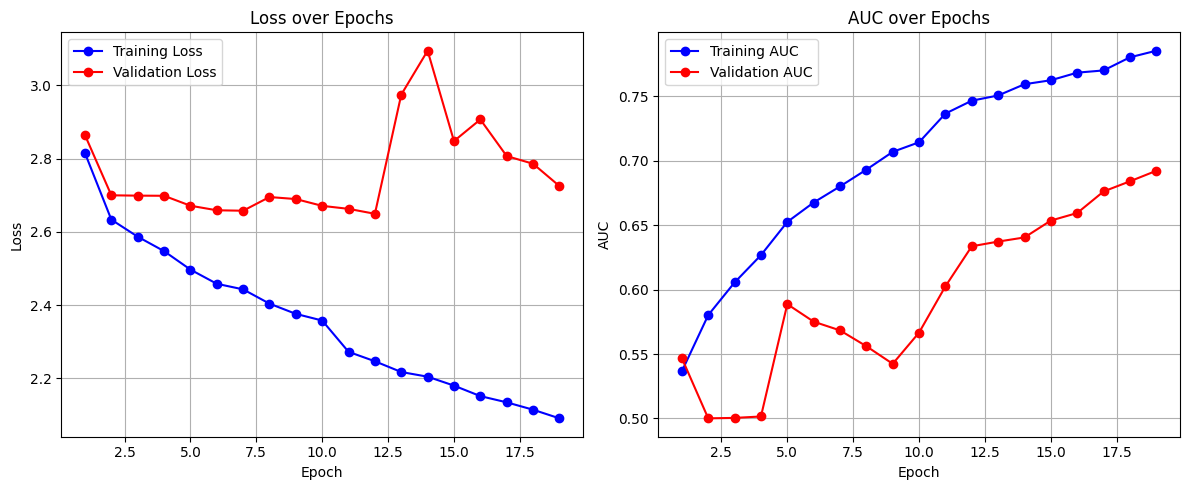

In [44]:
import matplotlib.pyplot as plt

history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history_dict['val_loss'], 'ro-', label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot AUC
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['auc'], 'bo-', label='Training AUC')
plt.plot(epochs, history_dict['val_auc'], 'ro-', label='Validation AUC')
plt.title('AUC over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
LAST_CONV = 'Conv_1'            # last conv layer in MobileNetV2

def get_gradcam_heatmap(img_tensor, model, last_conv_layer=LAST_CONV):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_tensor)
        class_idx      = tf.argmax(pred[0])
        loss           = pred[:, class_idx]

    grads = tape.gradient(loss, conv_out)     
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]                           # (H,W,C)
    heatmap  = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap  = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy(), int(class_idx)

In [58]:
def overlay_heatmap(orig_gray, heatmap, alpha=0.45, cmap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (orig_gray.shape[1], orig_gray.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cmap)[..., ::-1] / 255.0   
    orig_rgb = np.stack([orig_gray]*3, axis=-1) / 255.0            

    overlay  = alpha * heatmap + (1 - alpha) * orig_rgb
    overlay  = np.clip(overlay, 0, 1)
    return overlay

In [59]:
def gradcam_for_row(row, model):
    img_path = os.path.join(image_dir, row['Image'])   
    raw      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    raw_rgb  = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)

    prep = preprocess_pipeline(img_path)              
    tensor = np.expand_dims(prep, 0)

    raw_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)   # (H,W)
    heatmap, pred_idx = get_gradcam_heatmap(tensor, model)
    overlay = overlay_heatmap(raw_gray, heatmap)
    
    true_cls = row[disease_columns].idxmax()
    pred_cls = disease_columns[pred_idx]
    return overlay, true_cls, pred_cls

In [62]:
probs  = model.predict(BalancedGenerator(test_df, mode='test'), verbose=1)
pred_y = np.argmax(probs, axis=1)
test_df = test_df.copy()
test_df['pred'] = [disease_columns[i] for i in pred_y]

# pick 1 row per class where prediction == truth
samples = []
for cls in disease_columns:
    true_cls_rows = test_df[test_df['target'] == cls]
    correct_rows  = true_cls_rows[true_cls_rows['pred'] == cls]
    chosen_row = (correct_rows.sample(1, random_state=0) if len(correct_rows)
                  else true_cls_rows.sample(1, random_state=0)).iloc[0]
    samples.append(chosen_row)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step


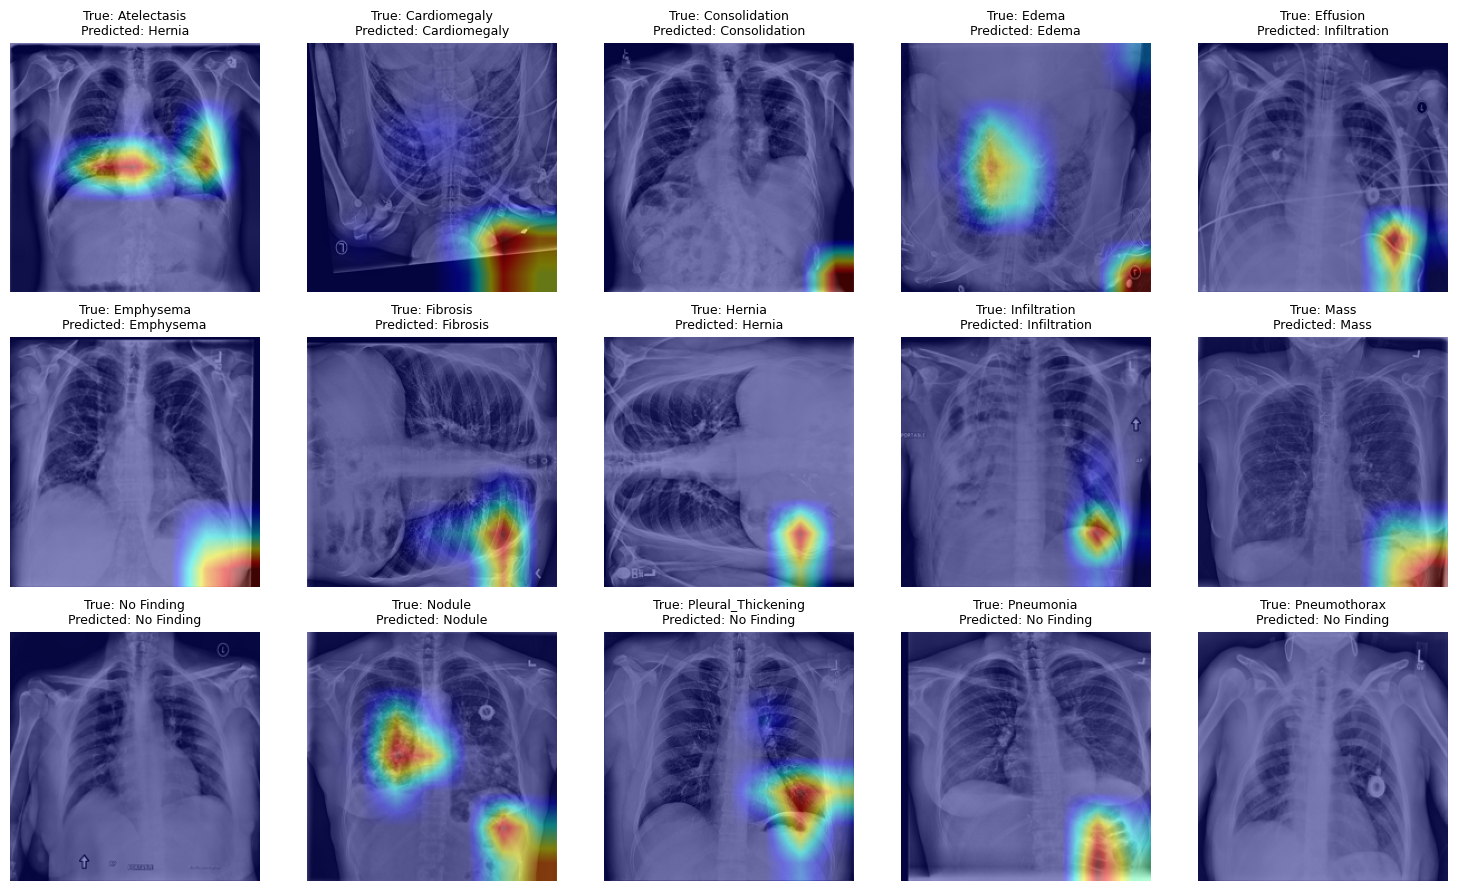

In [63]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, row in zip(axes, samples):
    overlay, t, p = gradcam_for_row(row, model)
    ax.imshow(overlay)
    ax.set_title(f"True: {t}\nPredicted: {p}", fontsize=9)
    ax.axis('off')

plt.tight_layout(); plt.show()

In [65]:
!pip -q install shap --upgrade           
import shap, numpy as np, cv2, os, random, matplotlib.pyplot as plt
import tensorflow as tf            

In [66]:
bg_rows = train_df.sample(n=min(100, len(train_df)), random_state=0)

background = []
for _, row in bg_rows.iterrows():
    img_path = os.path.join(image_dir, row['Image'])
    background.append(preprocess_pipeline(img_path))
background = np.stack(background, axis=0)     

In [68]:
explain_rows = []
for cls in disease_columns:
    correct = test_df[(test_df['target'] == cls) & (test_df['pred'] == cls)]
    row = (correct.sample(1, random_state=0) if len(correct)
           else test_df[test_df['target'] == cls].sample(1, random_state=0)
          ).iloc[0]
    explain_rows.append(row)

# load + preprocess
explain_imgs, explain_raw, explain_labels = [], [], []
for row in explain_rows:
    p = os.path.join(image_dir, row['Image'])
    explain_imgs.append(preprocess_pipeline(p))
    explain_raw.append(cv2.imread(p, cv2.IMREAD_GRAYSCALE))
    explain_labels.append(row['target'])
explain_imgs = np.stack(explain_imgs, axis=0)      

In [75]:
masker   = shap.maskers.Image("inpaint_telea", (224, 224, 3))
explainer = shap.Explainer(model, masker, output_names=disease_columns)

In [ ]:
shap_values = explainer(explain_imgs)            # no error
shap.image_plot(shap_values, -explain_imgs)

pred_idx = np.argmax(model.predict(explain_imgs), axis=1)
sv = np.zeros_like(explain_imgs)
for i, cls_idx in enumerate(pred_idx):
    sv[i] = shap_values[cls_idx][i]

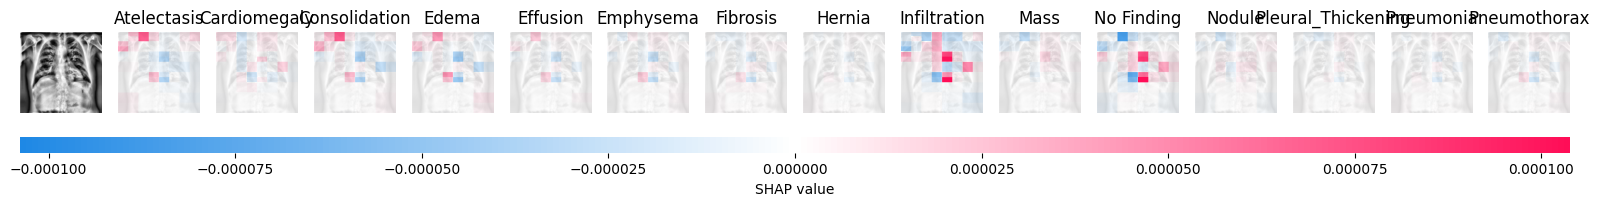

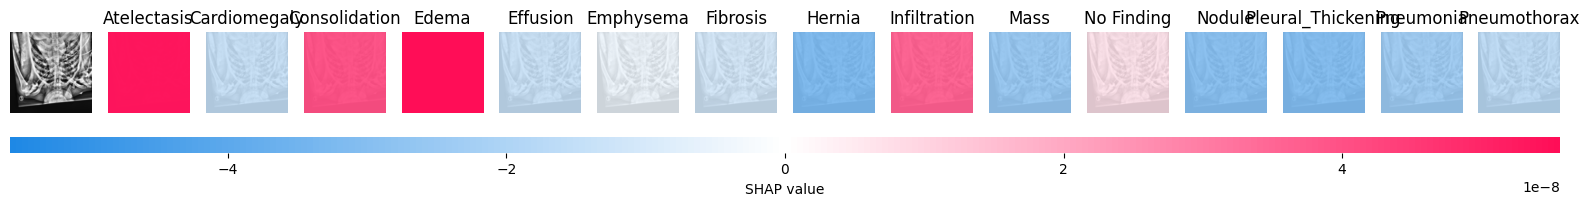

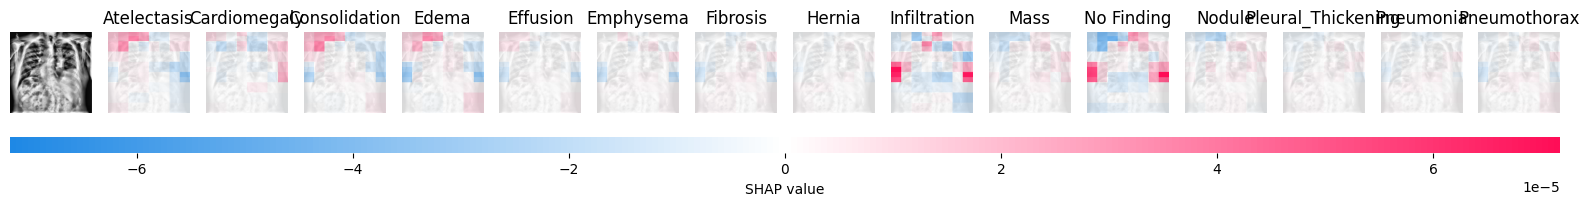

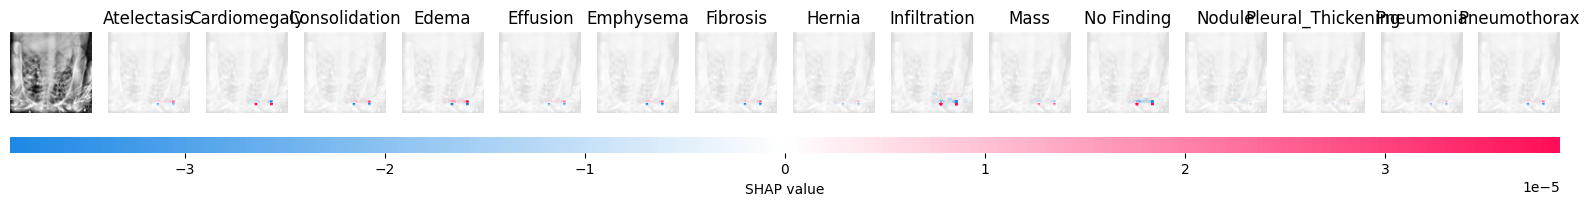

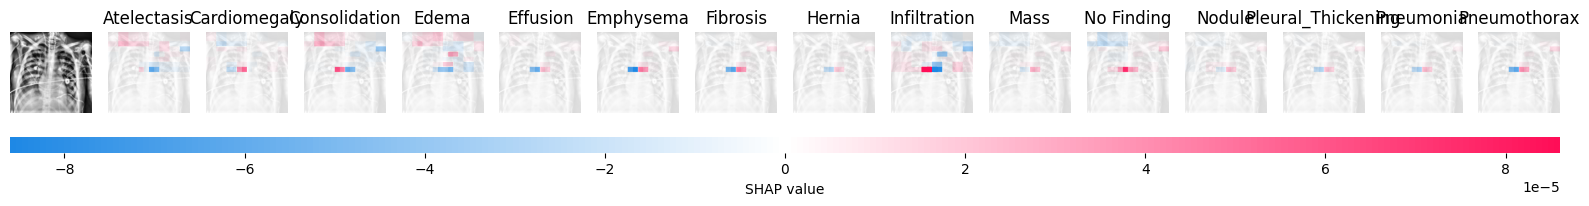

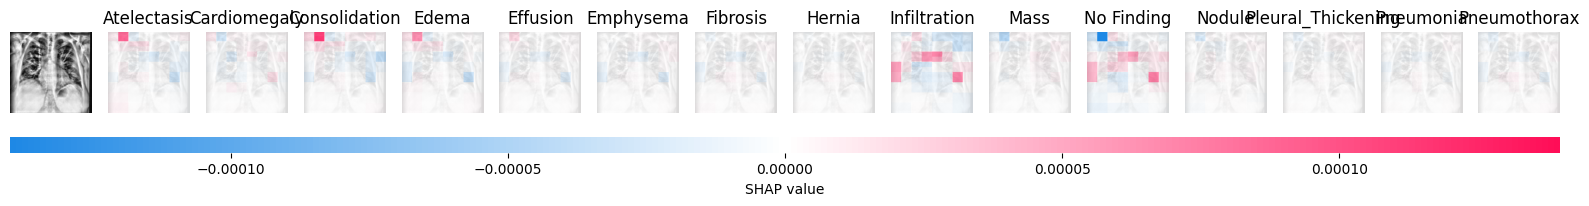

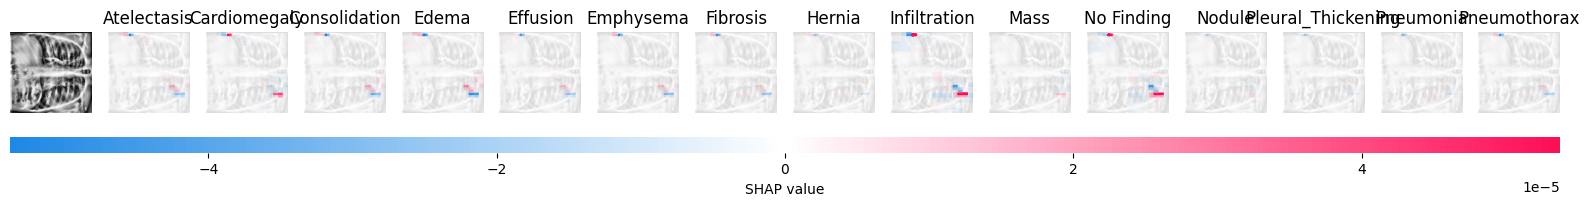

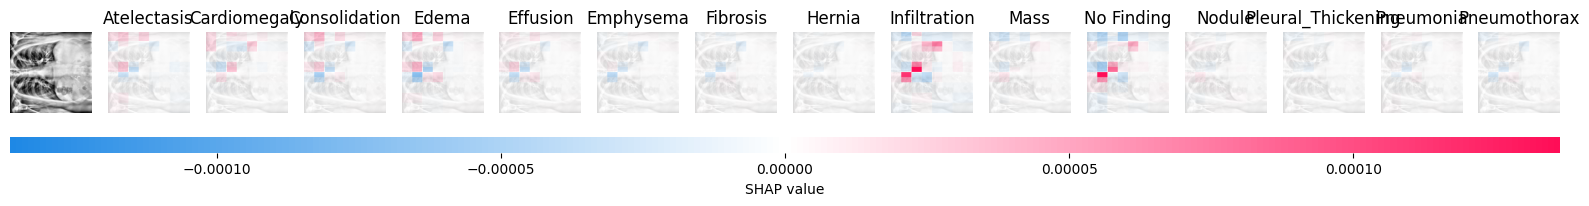

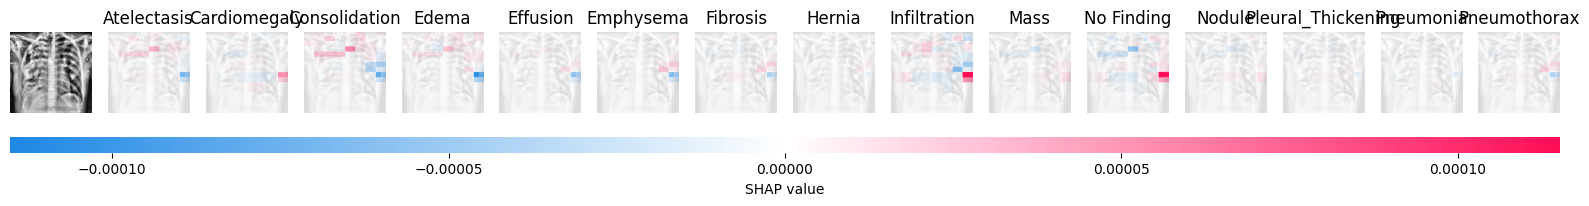

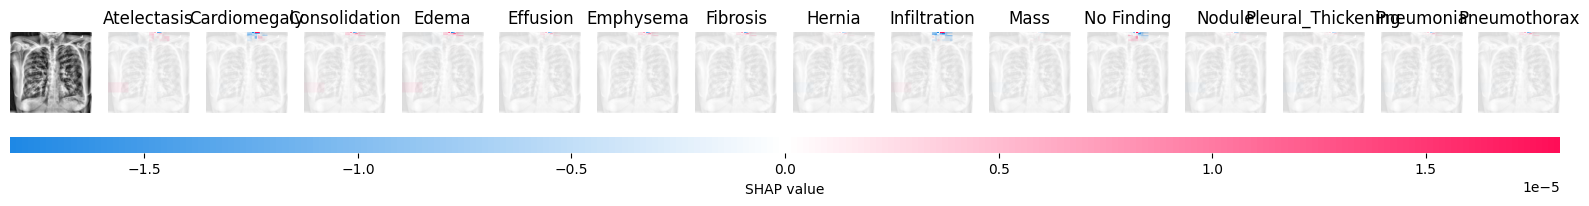

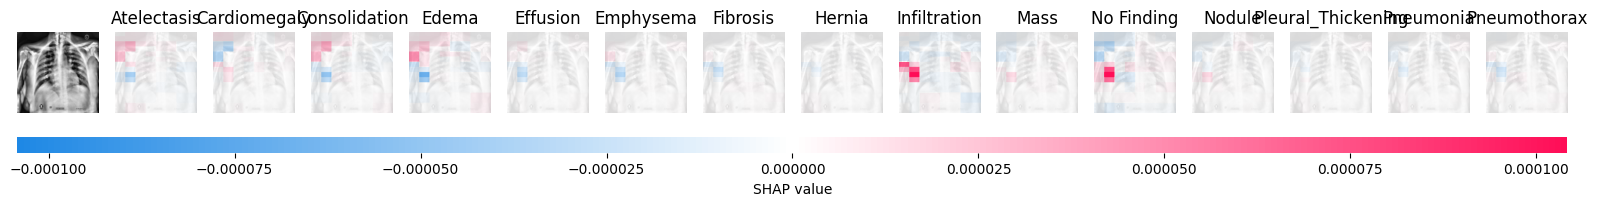

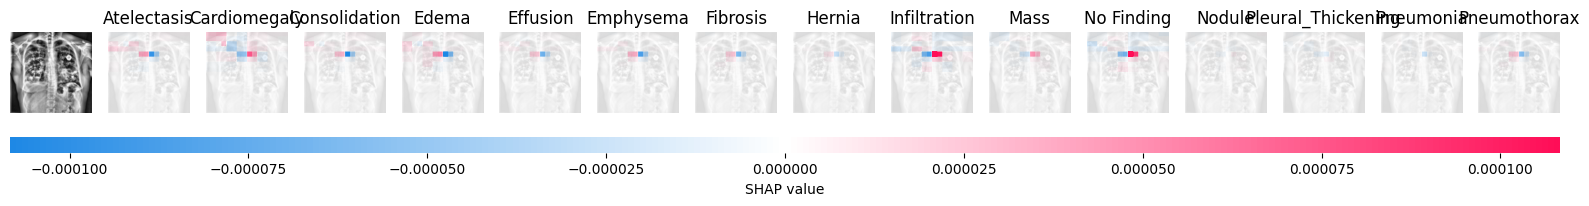

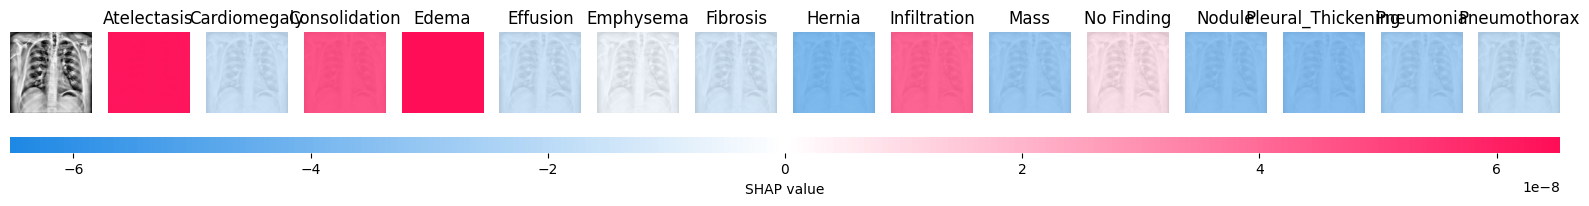

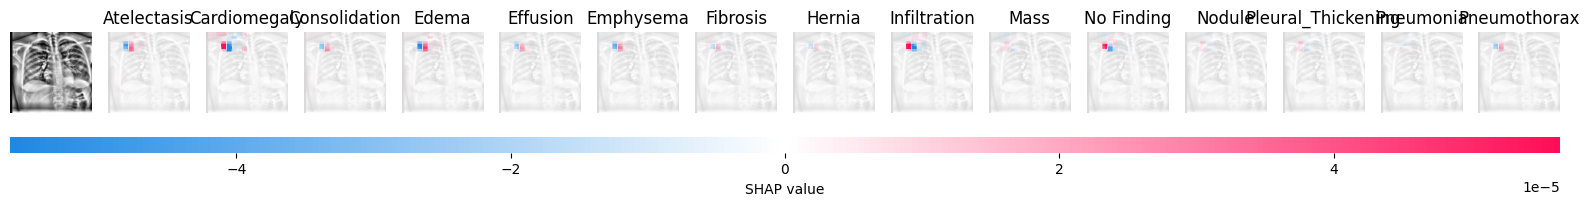

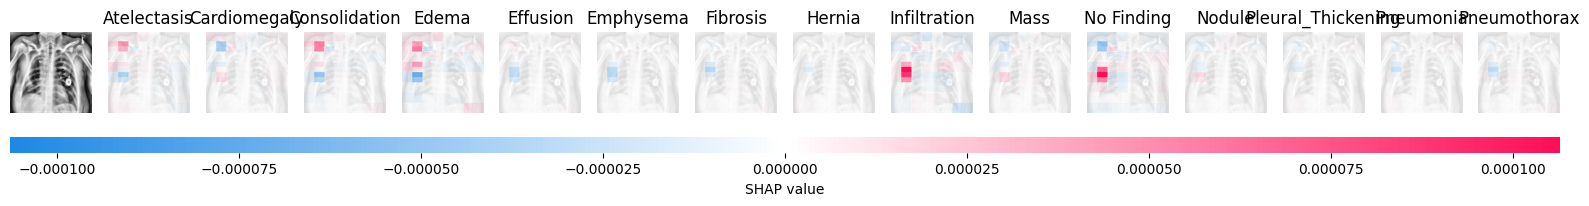

In [82]:
for i in range(len(explain_imgs)):
    shap.plots.image(shap_values[i],
                     show=True,         
                    )           

In [83]:
!pip -q install lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt, cv2, numpy as np, os, random, warnings
warnings.filterwarnings("ignore")

In [84]:
def lime_predict(batch_uint8):
    batch_pp = []
    for img in batch_uint8:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        cv2.imwrite('/tmp/tmp.png', gray)        
        batch_pp.append(preprocess_pipeline('/tmp/tmp.png'))
    return model.predict(np.stack(batch_pp))

In [87]:
explainer_lime = lime_image.LimeImageExplainer()

def lime_explain_single(raw_gray_uint8):
    rgb = cv2.cvtColor(raw_gray_uint8, cv2.COLOR_GRAY2RGB)
    segmenter = lime_image.SegmentationAlgorithm(
                    'quickshift', kernel_size=4, max_dist=200, ratio=0.2)

    explanation = explainer_lime.explain_instance(
        rgb,
        classifier_fn=lime_predict,
        top_labels=1,
        num_samples=1000,
        segmentation_fn=segmenter
    )

    label = explanation.top_labels[0]
    mask  = explanation.get_image_and_mask(
               label, positive_only=True, hide_rest=False, num_features=5)[1]

    marked = mark_boundaries(
                cv2.cvtColor(raw_gray_uint8, cv2.COLOR_GRAY2RGB)/255.0, mask,
                color=(1,0,0))
    return (marked*255).astype('uint8')

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

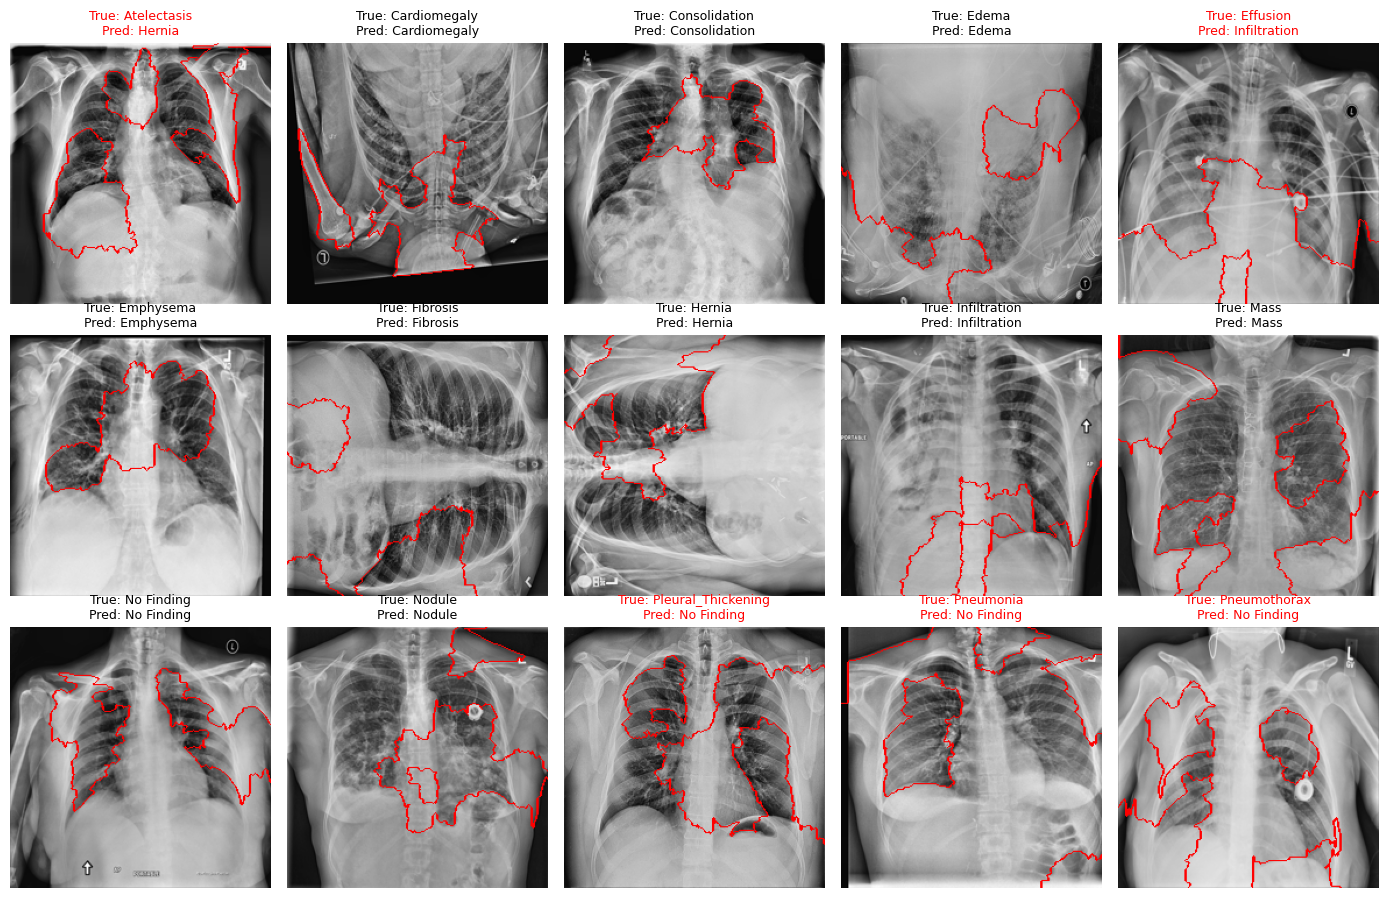

In [88]:
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
axes = axes.flatten()

for k, ax in enumerate(axes):
    if k >= len(explain_rows):
        ax.axis('off'); continue

    row       = explain_rows[k]
    img_path  = os.path.join(image_dir, row['Image'])
    raw_gray  = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    overlay   = lime_explain_single(raw_gray)

    # titles
    true_cls  = row['target']
    pred_cls  = disease_columns[np.argmax(model.predict(explain_imgs[k:k+1]))]
    colour    = 'black' if true_cls == pred_cls else 'red'

    ax.imshow(overlay); ax.axis('off')
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls}",
                 fontsize=9, color=colour)

plt.tight_layout(); plt.show()

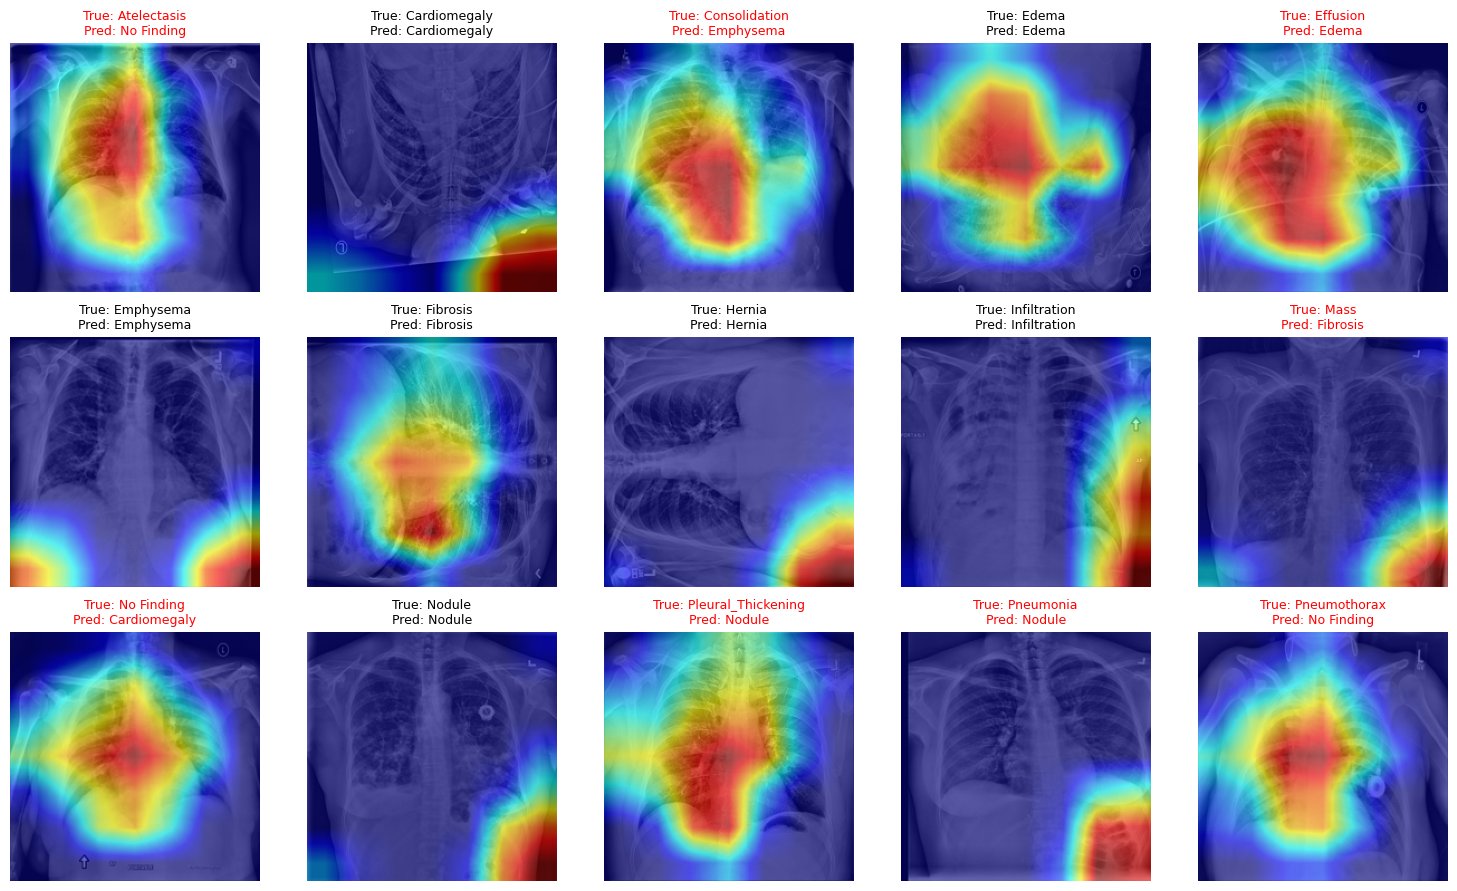

In [107]:
LAYER_NAME = 'Conv_1'            

feat_extractor = tf.keras.Model(inputs=model.input,
                                outputs=[model.get_layer(LAYER_NAME).output,
                                         model.output])

def eigen_cam(batch224):
    fmap, logits = feat_extractor(batch224, training=False)
    pred_idx     = int(tf.argmax(logits[0]))
    fmap   = fmap[0].numpy()                     # (Hf,Wf,C)
    Hf,Wf,C = fmap.shape
    mat     = fmap.reshape(-1, C)
    mat    -= mat.mean(0, keepdims=True)
    u,_,_   = np.linalg.svd(mat, full_matrices=False)
    cam     = u[:,0].reshape(Hf, Wf)
    cam     = np.maximum(cam, 0)
    cam     = (cam-cam.min())/(cam.max()+1e-9)
    cam     = cv2.resize(cam, (224,224), cv2.INTER_CUBIC)
    heat    = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heat    = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)/255.
    return heat, pred_idx
    
samples = []
for cls in disease_columns:
    corr = test_df[(test_df['target']==cls) & (test_df['pred']==cls)]
    row  = (corr.sample(1, random_state=0) if len(corr)
            else test_df[test_df['target']==cls].sample(1, random_state=0)
           ).iloc[0]
    samples.append(row)

fig, axes = plt.subplots(3,5, figsize=(15,9))
axes = axes.flatten()

for ax, row in zip(axes, samples):
    img_path   = os.path.join(image_dir, row['Image'])
    raw_gray   = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    prep       = preprocess_pipeline(img_path)[None,...]  
    heat, pred = eigen_cam(prep)
    overlay    = 0.6*heat + 0.4*np.stack([raw_gray/255.]*3, -1)

    true_cls   = row['target']
    pred_cls   = disease_columns[pred]
    color      = 'black' if true_cls==pred_cls else 'red'

    ax.imshow(overlay); ax.axis('off')
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls}", fontsize=9, color=color)

plt.tight_layout(); plt.show()